In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\91882\Desktop\AI-Based Email Spam Detection\data\email_text.csv")
df.sample(5)

,label,text
3418,0,tim one effect of getting rid of mincount is ...
3541,0,july escapenumber escapenumber from escapelong...
3387,0,chris garrigues said done i also eliminated t...
3924,0,matthias on mon sep escapenumber escapenumber ...
4987,1,obtain a prosperous future money earning power...


In [17]:
df['label'].value_counts()

label
0    4072
1    1568
Name: count, dtype: int64

In [7]:
df['label'].value_counts(normalize=True) * 100

label
0    72.198582
1    27.801418
Name: proportion, dtype: float64

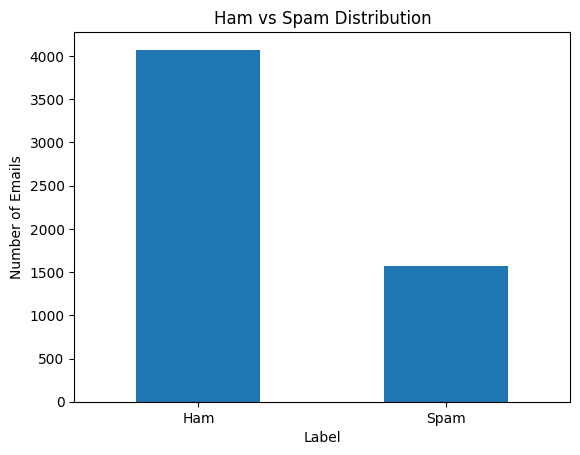

In [12]:
df['label'].value_counts().plot(kind = 'bar')
plt.title("Ham vs Spam Distribution")
plt.xlabel('Label')
plt.ylabel('Number of Emails')
plt.xticks([0, 1], ['Ham', 'Spam'], rotation=0)
plt.show()

In [13]:
df['email_length'] = df['text'].str.len()

In [16]:
df.groupby('label')['email_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4072.0,1762.782908,4473.519604,31.0,517.0,938.0,1613.25,159059.0
1,1568.0,2506.072704,5652.463849,11.0,671.0,1066.0,2110.00,81041.0


In [14]:
df.sample(5)

,label,text,email_length
1503,0,on monday september escapenumber escapenumber ...,372
4239,1,this is definitely the answer we all have bee...,3231
3462,0,i've got some really interesting wav files her...,2062
895,0,done robert elz said i suspect that as part of...,1373
663,0,j jim whitehead writes j you open sourced the...,667


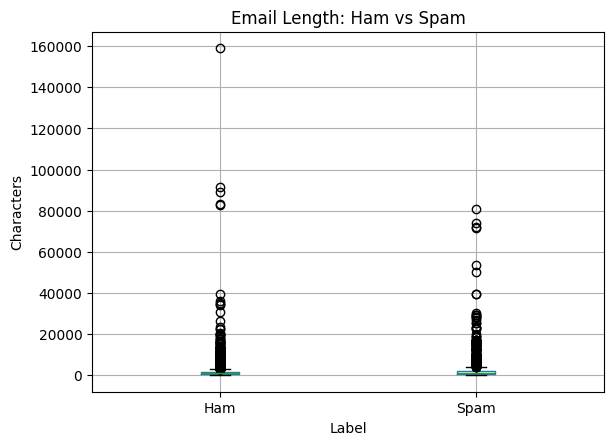

In [18]:
import matplotlib.pyplot as plt

df.boxplot(column='email_length', by='label')

plt.title('Email Length: Ham vs Spam')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Characters')
plt.xticks([1, 2], ['Ham', 'Spam'])
plt.show()

In [19]:
df.groupby('label')['email_length'].mean()

label
0    1762.782908
1    2506.072704
Name: email_length, dtype: float64

## Common Words

In [23]:
from collections import Counter
import re
spam_txt = ''.join(df[df['label'] == 1]['text']).lower()
words = re.findall(r'\b[a-z]+\b', spam_txt)
Counter(words).most_common(20)

[('escapenumber', 31774),
 ('the', 17728),
 ('to', 16113),
 ('and', 11940),
 ('you', 11662),
 ('of', 10630),
 ('escapelong', 10066),
 ('a', 8736),
 ('your', 6957),
 ('for', 6690),
 ('in', 6672),
 ('is', 5475),
 ('this', 5412),
 ('escapenumbere', 4106),
 ('i', 4066),
 ('it', 3589),
 ('that', 3554),
 ('on', 3446),
 ('with', 3350),
 ('or', 3301)]

## Common words in spam

In [24]:
# we will skip comkon english words

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

spam_words = [
    word for word in words
    if word not in ENGLISH_STOP_WORDS
]

Counter(spam_words).most_common(20)

[('escapenumber', 31774),
 ('escapelong', 10066),
 ('escapenumbere', 4106),
 ('escapenumberd', 2676),
 ('s', 2675),
 ('com', 2636),
 ('email', 2413),
 ('free', 2245),
 ('bescapenumber', 2205),
 ('http', 2125),
 ('descapenumber', 2108),
 ('escapenumberc', 2106),
 ('aescapenumber', 1932),
 ('cescapenumber', 1890),
 ('e', 1826),
 ('click', 1575),
 ('mail', 1488),
 ('t', 1472),
 ('money', 1465),
 ('business', 1416)]

## Common words in Ham

In [25]:
ham_text = ' '.join(df[df['label'] == 0]['text']).lower()

ham_words = re.findall(r'\b[a-z]+\b', ham_text)

ham_words = [
    word for word in ham_words
    if word not in ENGLISH_STOP_WORDS
]

Counter(ham_words).most_common(20)

[('escapenumber', 55930),
 ('http', 10940),
 ('s', 9193),
 ('com', 8857),
 ('www', 5820),
 ('t', 5338),
 ('net', 4163),
 ('list', 3760),
 ('linux', 3756),
 ('escapelong', 2480),
 ('users', 2442),
 ('just', 2373),
 ('listinfo', 2291),
 ('use', 2258),
 ('lists', 2240),
 ('new', 2107),
 ('org', 2037),
 ('like', 2004),
 ('m', 1984),
 ('time', 1874)]

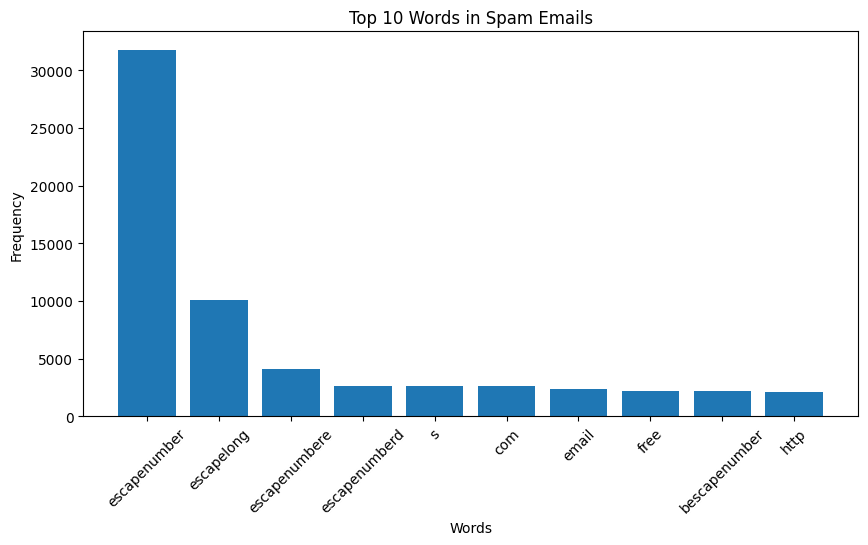

In [28]:
spam_top_words = Counter(spam_words).most_common(10)

words, counts = zip(*spam_top_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts)

plt.title('Top 10 Words in Spam Emails')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()